In [112]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Insert warehouse name here
warehouse_name = "OE"
# Insert user id here
user = "betsyfrdmn"
# GitHub repo
base = "Lucas_Systems_Capstone_Project"

# Load your processed data
df = pd.read_parquet(f"/Users/{user}/{base}/data/processed/oe_detailed.parquet")

# Filter for only Work Code 30
df = df[df["WorkCode"] == "30"]

# Drop missing rows for important variables
df = df.dropna(subset=['Weight', 'Cube', 'Level', 'Time_Delta_sec', 'Travel_Distance'])

In [113]:
X = df[['Weight', 'Cube', 'Level', 'Travel_Distance']]
y = df['Time_Delta_sec']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5 neighbors, uniform weighting, with Travel Distance
knn = KNeighborsRegressor(n_neighbors=5, weights='uniform')
knn.fit(X_train_scaled, y_train)

predictions = knn.predict(X_test_scaled)

mae = mean_absolute_error(y_test, predictions)

print(f"Mean Absolute Error: {mae}")



Mean Absolute Error: 58.39187302128922


In [114]:
X = df[['Weight', 'Cube', 'Level', 'Travel_Distance']]
y = df['Time_Delta_sec']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5 neighbors, distance weighting, with Travel Distance
knn = KNeighborsRegressor(n_neighbors=5, weights='distance')
knn.fit(X_train_scaled, y_train)

predictions = knn.predict(X_test_scaled)

mae = mean_absolute_error(y_test, predictions)

print(f"Mean Absolute Error: {mae}")



Mean Absolute Error: 59.13635403913226


In [115]:
X = df[['Weight', 'Cube', 'Level', 'Travel_Distance']]
y = df['Time_Delta_sec']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 10 neighbors, uniform weighting, with Travel Distance
knn = KNeighborsRegressor(n_neighbors=10, weights='uniform')
knn.fit(X_train_scaled, y_train)

predictions = knn.predict(X_test_scaled)

mae = mean_absolute_error(y_test, predictions)

print(f"Mean Absolute Error: {mae}")




Mean Absolute Error: 57.548284244492244


In [116]:
X = df[['Weight', 'Cube', 'Level', 'Travel_Distance']]
y = df['Time_Delta_sec']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 10 neighbors, distance weighting, with Travel Distance
knn = KNeighborsRegressor(n_neighbors=10, weights='distance')
knn.fit(X_train_scaled, y_train)

predictions = knn.predict(X_test_scaled)

mae = mean_absolute_error(y_test, predictions)

print(f"Mean Absolute Error: {mae}")




Mean Absolute Error: 57.88467008439773


The optimal number of neighbors is: 40


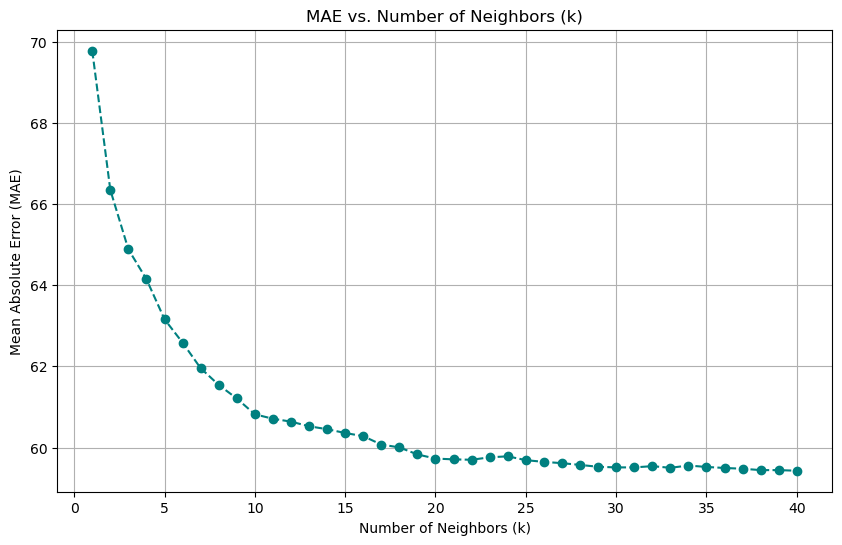

In [117]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

# 1. Scale your features (Mandatory for kNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# 2. Iterate through potential k values
k_range = range(1, 41)
mae_scores = []

for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    # Using negative MAE because cross_val_score follows 'higher is better'
    scores = cross_val_score(knn, X_scaled, y_train, cv=10, scoring='neg_mean_absolute_error')
    mae_scores.append(-scores.mean())

# 3. Find the minimum MAE
best_k = k_range[np.argmin(mae_scores)]
print(f"The optimal number of neighbors is: {best_k}")

# 4. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(k_range, mae_scores, marker='o', linestyle='--', color='teal')
plt.title('MAE vs. Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Absolute Error (MAE)')
plt.grid(True)
plt.show()

In [118]:
X = df[['Weight', 'Cube', 'Level']]
y = df['Time_Delta_sec']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 10 neighbors, uniform weighting, no Travel Distance
knn = KNeighborsRegressor(n_neighbors=10, weights='uniform')
knn.fit(X_train_scaled, y_train)

predictions = knn.predict(X_test_scaled)

mae = mean_absolute_error(y_test, predictions)

print(f"Mean Absolute Error: {mae}")

Mean Absolute Error: 63.841217253912916


In [119]:
X = df[['Weight', 'Cube', 'Level']]
y = df['Time_Delta_sec']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 10 neighbors, distance weighting, no Travel Distance
knn = KNeighborsRegressor(n_neighbors=10, weights='distance')
knn.fit(X_train_scaled, y_train)

predictions = knn.predict(X_test_scaled)

mae = mean_absolute_error(y_test, predictions)

print(f"Mean Absolute Error: {mae}")



Mean Absolute Error: 64.4370365792091
